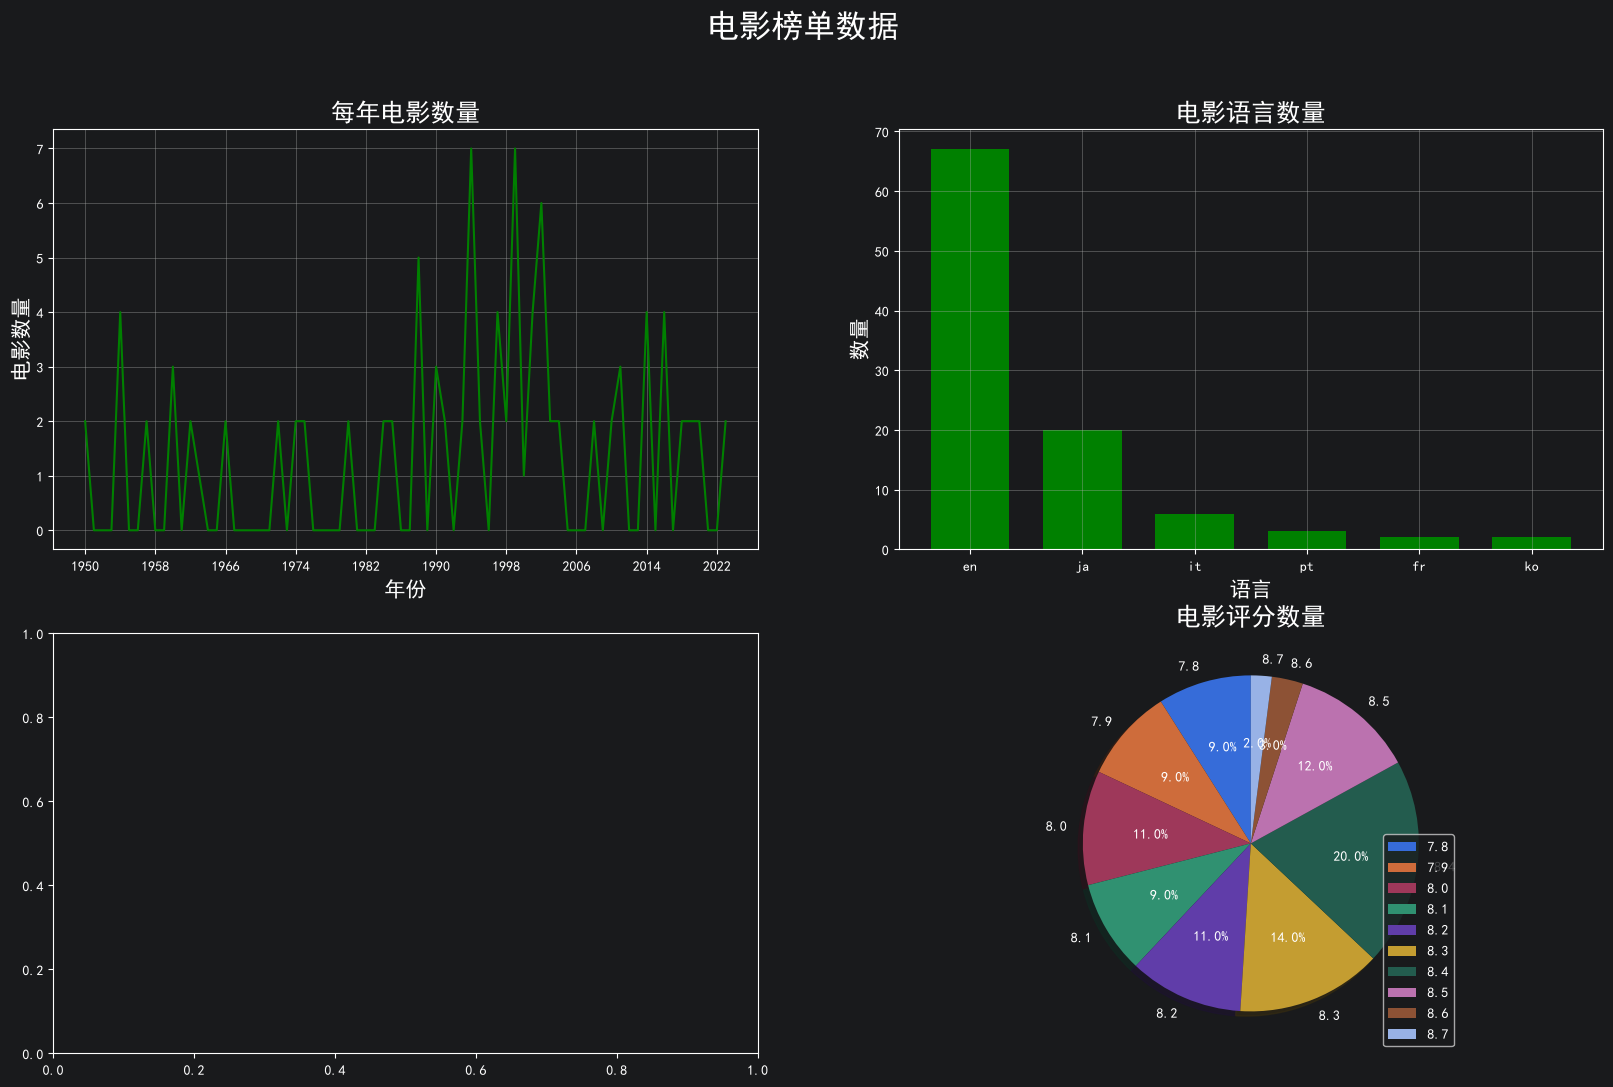

In [72]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
# 显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']
# 创建子图
fig ,ax = plt.subplots(nrows=2,ncols=2,figsize=(20,12),dpi = 100)
fig.suptitle("电影榜单数据",fontsize = 23)
#获取子图
axes1:Axes = ax[0,0]
axes2:Axes = ax[0,1]
axes3:Axes = ax[1,0]
axes4:Axes = ax[1,1]


#加载数据
data = pd.read_csv('data/电影表单.csv',usecols=['电影名称','上映日期','评分','原始语言'])

#处理缺失异常值
#查看
# data.isnull().sum()
# 增加年份列
data['年份']=pd.to_numeric(data['上映日期'].str[:4], errors='coerce')

#统计分组
year_count=data.groupby('年份')['年份'].count()

#组装数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year,max_year+1)]


y = [int(year_count.get(i,0)) for i in x ]


axes1.plot(x,y,color = "green")
axes1.set_title("每年电影数量",fontsize = 18)
axes1.set_xlabel("年份",fontsize = 15)
axes1.set_ylabel("电影数量",fontsize = 15)
axes1.set_xticks(x[::8])
axes1.grid()

#2.统计语言
language_count = data.groupby('原始语言')['原始语言'].count().sort_values(ascending=False)

x_language = language_count.index.tolist()
y_language = language_count.values.tolist()


axes2.bar(x_language,y_language,color = "green",width=0.7)
axes2.set_title("电影语言数量",fontsize = 18)
axes2.set_xlabel("语言",fontsize = 15)
axes2.set_ylabel("数量",fontsize = 15)

axes2.tick_params(axis='x')
axes2.grid()


#统计不同评分电影的数量

score_count = data['评分'].round(1).value_counts().sort_index()\

total = score_count.sum()


scores = score_count.index.tolist()
counts_values = score_count.values.tolist()

axes4 .pie(counts_values,labels=scores,autopct='%1.1f%%',shadow=True,startangle=90)

axes4.set_title("电影评分数量",fontsize = 18,)
axes4.legend()

